In [ ]:
# this installs Julia 1.7
%%capture
%%shell
wget -O - https://raw.githubusercontent.com/JuliaAI/Imbalance.jl/dev/docs/src/examples/colab.sh | bash
#This should take around one minute to finish. Once it does, change the runtime to `Julia` by choosing `Runtime` 
# from the toolbar then `Change runtime type`. You can then delete this cell.

# Effect of ENN Hyperparameters

In [19]:
import Pkg;
Pkg.add(["Random", "CSV", "DataFrames", "MLJ", "Imbalance", 
         "ScientificTypes",  "Plots", "Measures", "HTTP"])

using Random
using CSV
using DataFrames
using MLJ
using Imbalance
using ScientificTypes
using Plots, Measures
using HTTP: download

## Loading Data
In this example, we will consider the [BMI dataset](https://www.kaggle.com/datasets/yasserh/bmidataset) found on Kaggle where the objective is to predict the BMI index of individuals given their gender, weight and height. 

`CSV` gives us the ability to easily read the dataset after it's downloaded as follows



In [10]:
datafile = download("https://raw.githubusercontent.com/JuliaAI/Imbalance.jl/dev/docs/src/examples/effect_of_k_enn/bmi.csv")
df = CSV.read(datafile, DataFrame)

# Display the first 5 rows with DataFrames
first(df, 5) |> pretty

┌─────────┬────────┬────────┬───────┐
│ Gender  │ Height │ Weight │ Index │
│ String7 │ Int64  │ Int64  │ Int64 │
│ Textual │ Count  │ Count  │ Count │
├─────────┼────────┼────────┼───────┤
│ Male    │ 174    │ 96     │ 4     │
│ Male    │ 189    │ 87     │ 2     │
│ Female  │ 185    │ 110    │ 4     │
│ Female  │ 195    │ 104    │ 3     │
│ Male    │ 149    │ 61     │ 3     │
└─────────┴────────┴────────┴───────┘


We will drop the gender attribute for purposes of visualization and to have more options for the model.

In [11]:
select!(df, Not(:Gender)) |> pretty

┌────────┬────────┬───────┐
│ Height │ Weight │ Index │
│ Int64  │ Int64  │ Int64 │
│ Count  │ Count  │ Count │
├────────┼────────┼───────┤
│ 174    │ 96     │ 4     │
│ 189    │ 87     │ 2     │
│ 185    │ 110    │ 4     │
│ 195    │ 104    │ 3     │
│ 149    │ 61     │ 3     │
│ 189    │ 104    │ 3     │
│ 147    │ 92     │ 5     │
│ 154    │ 111    │ 5     │
│ 174    │ 90     │ 3     │
│ 169    │ 103    │ 4     │
│ 195    │ 81     │ 2     │
│ 159    │ 80     │ 4     │
│ 192    │ 101    │ 3     │
│ 155    │ 51     │ 2     │
│ 191    │ 79     │ 2     │
│ 153    │ 107    │ 5     │
│ 157    │ 110    │ 5     │
│ 140    │ 129    │ 5     │
│ 144    │ 145    │ 5     │
│ 172    │ 139    │ 5     │
│ 157    │ 110    │ 5     │
│ 153    │ 149    │ 5     │
│ 169    │ 97     │ 4     │
│ 185    │ 139    │ 5     │
│ 172    │ 67     │ 2     │
│ 151    │ 64     │ 3     │
│ 190    │ 95     │ 3     │
│ 187    │ 62     │ 1     │
│ 163    │ 159    │ 5     │
│ 179    │ 152    │ 5     │
│ 153    │ 121    │ 

## Coercing Data



In [12]:
ScientificTypes.schema(df)

┌────────┬──────────┬───────┐
│ names  │ scitypes │ types │
├────────┼──────────┼───────┤
│ Height │ Count    │ Int64 │
│ Weight │ Count    │ Int64 │
│ Index  │ Count    │ Int64 │
└────────┴──────────┴───────┘


Weight and Height should be `Continuous` and Index should be an `OrderedFactor`


In [13]:
df = coerce(df,
            :Height => Continuous,
            :Weight => Continuous,
            :Index => OrderedFactor)
ScientificTypes.schema(df)

┌────────┬──────────────────┬─────────────────────────────────┐
│ names  │ scitypes         │ types                           │
├────────┼──────────────────┼─────────────────────────────────┤
│ Height │ Continuous       │ Float64                         │
│ Weight │ Continuous       │ Float64                         │
│ Index  │ OrderedFactor{6} │ CategoricalValue{Int64, UInt32} │
└────────┴──────────────────┴─────────────────────────────────┘


## Unpacking Data

Both `MLJ` and the pure functional interface of `Imbalance` assume that the observations table `X` and target vector `y` are separate. We can accomplish that by using `unpack` from `MLJ`



In [14]:
y, X = unpack(df, ==(:Index); rng=123);
first(X, 5) |> pretty

┌────────────┬────────────┐
│ Height     │ Weight     │
│ Float64    │ Float64    │
│ Continuous │ Continuous │
├────────────┼────────────┤
│ 172.0      │ 75.0       │
│ 183.0      │ 147.0      │
│ 172.0      │ 92.0       │
│ 149.0      │ 61.0       │
│ 160.0      │ 131.0      │
└────────────┴────────────┘


We will skip splitting the data since the main purpose of this tutorial is visualization.

## Undersampling

Before undersampling, let's check the balance of the data

In [25]:
checkbalance(y; ref="minority")

0: ▇▇▇ 13 (100.0%) 
1: ▇▇▇▇▇▇ 22 (169.2%) 
3: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 68 (523.1%) 
2: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 69 (530.8%) 
4: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 130 (1000.0%) 
5: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 198 (1523.1%) 


Let's use ENN undersampling to undersample the data. ENN undersamples the data by "cleaning it out" or in another words deleting any point that violates a certain condition. We can limit the number of points that are deleted by setting the `min_ratios` parameter. 

We will set `k=1` and `keep_condition="only mode"` which means that any point with a label that is not the only most common one amongst its 1-nearest neighbors will be deleted (i.e., must have same label as its nearest neighbor). By setting min_ratios=0.01 we set a very low bar, allowing ENN to delete points freely from all classes

In [16]:
min_ratios = Dict(class=>0.01 for class in levels(y))

Dict{Int64, Float64} with 6 entries:
  0 => 0.01
  4 => 0.01
  5 => 0.01
  2 => 0.01
  3 => 0.01
  1 => 0.01

In [17]:
X_under, y_under = enn_undersample(
	X,
	y;
	k = 1,
	keep_condition = "only mode",
	min_ratios,
	rng = 42,
)

(448×2 DataFrame
 Row │ Height   Weight  
     │ Float64  Float64 
─────┼──────────────────
   1 │   149.0     61.0
   2 │   187.0     89.0
   3 │   178.0     83.0
   4 │   184.0     86.0
   5 │   149.0     61.0
   6 │   161.0     72.0
   7 │   182.0     84.0
   8 │   190.0    105.0
   9 │   182.0     98.0
  10 │   194.0    106.0
  11 │   151.0     62.0
  ⋮  │    ⋮        ⋮
 439 │   190.0     50.0
 440 │   193.0     54.0
 441 │   198.0     50.0
 442 │   188.0     54.0
 443 │   181.0     51.0
 444 │   183.0     50.0
 445 │   191.0     54.0
 446 │   196.0     50.0
 447 │   182.0     50.0
 448 │   190.0     50.0
        427 rows omitted, CategoricalArrays.CategoricalValue{Int64, UInt32}[3, 3, 3, 3, 3, 3, 3, 3, 3, 3  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [18]:
checkbalance(y_under; ref="minority")

0: ▇▇▇ 12 (100.0%) 
1: ▇▇▇▇▇ 20 (166.7%) 
2: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 55 (458.3%) 
3: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 58 (483.3%) 
4: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 114 (950.0%) 
5: ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇ 189 (1575.0%) 


## Training the Model



Because we have scientific types setup, we can easily check what models will be able to train on our data. This should guarantee that the model we choose won't throw an error due to types after feeding it the data.


In [19]:
models(matching(X_under, y_under))

54-element Vector{NamedTuple{(:name, :package_name, :is_supervised, :abstract_type, :deep_properties, :docstring, :fit_data_scitype, :human_name, :hyperparameter_ranges, :hyperparameter_types, :hyperparameters, :implemented_methods, :inverse_transform_scitype, :is_pure_julia, :is_wrapper, :iteration_parameter, :load_path, :package_license, :package_url, :package_uuid, :predict_scitype, :prediction_type, :reporting_operations, :reports_feature_importances, :supports_class_weights, :supports_online, :supports_training_losses, :supports_weights, :transform_scitype, :input_scitype, :target_scitype, :output_scitype)}}:
 (name = AdaBoostClassifier, package_name = MLJScikitLearnInterface, ... )
 (name = AdaBoostStumpClassifier, package_name = DecisionTree, ... )
 (name = BaggingClassifier, package_name = MLJScikitLearnInterface, ... )
 (name = BayesianLDA, package_name = MLJScikitLearnInterface, ... )
 (name = BayesianLDA, package_name = MultivariateStats, ... )
 (name = BayesianQDA, package_

Let's go for an `SVM` from `LIBSVM`

In [ ]:
import Pkg; Pkg.add("LIBSVM")
import LIBSVM;

### Before Undersampling


In [21]:
# 1. Load the model
SVC = @load SVC pkg=LIBSVM

# 2. Instantiate it
model = SVC(kernel=LIBSVM.Kernel.RadialBasis, gamma=0.01) ## instance

# 3. Wrap it with the data in a machine
mach = machine(model, X, y)

# 4. fit the machine learning model
fit!(mach)

[ Info: For silent loading, specify `verbosity=0`. 


import MLJLIBSVMInterface ✔


[ Info: Training machine(SVC(kernel = RadialBasis, …), …).


trained Machine; caches model-specific representations of data
  model: SVC(kernel = RadialBasis, …)
  args: 
    1:	Source @579 ⏎ Table{AbstractVector{Continuous}}
    2:	Source @973 ⏎ AbstractVector{OrderedFactor{6}}


### After Undersampling


In [22]:
# 3. Wrap it with the data in a machine
mach_under = machine(model, X_under, y_under)

# 4. fit the machine learning model
fit!(mach_under)

[ Info: Training machine(SVC(kernel = RadialBasis, …), …).


trained Machine; caches model-specific representations of data
  model: SVC(kernel = RadialBasis, …)
  args: 
    1:	Source @827 ⏎ Table{AbstractVector{Continuous}}
    2:	Source @664 ⏎ AbstractVector{OrderedFactor{6}}


## Plot Decision Boundaries

Construct ranges for each feature and consecutively a grid

In [23]:
height_range =
	range(minimum(X.Height) - 1, maximum(X.Height) + 1, length = 400)
weight_range =
range(minimum(X.Weight) - 1, maximum(X.Weight) + 1, length = 400)
grid_points = [(h, w) for h in height_range, w in weight_range]

400×400 Matrix{Tuple{Float64, Float64}}:
 (139.0, 49.0)    (139.0, 49.2807)    (139.0, 49.5614)    …  (139.0, 161.0)
 (139.153, 49.0)  (139.153, 49.2807)  (139.153, 49.5614)     (139.153, 161.0)
 (139.306, 49.0)  (139.306, 49.2807)  (139.306, 49.5614)     (139.306, 161.0)
 (139.459, 49.0)  (139.459, 49.2807)  (139.459, 49.5614)     (139.459, 161.0)
 (139.612, 49.0)  (139.612, 49.2807)  (139.612, 49.5614)     (139.612, 161.0)
 (139.764, 49.0)  (139.764, 49.2807)  (139.764, 49.5614)  …  (139.764, 161.0)
 (139.917, 49.0)  (139.917, 49.2807)  (139.917, 49.5614)     (139.917, 161.0)
 (140.07, 49.0)   (140.07, 49.2807)   (140.07, 49.5614)      (140.07, 161.0)
 (140.223, 49.0)  (140.223, 49.2807)  (140.223, 49.5614)     (140.223, 161.0)
 (140.376, 49.0)  (140.376, 49.2807)  (140.376, 49.5614)     (140.376, 161.0)
 (140.529, 49.0)  (140.529, 49.2807)  (140.529, 49.5614)  …  (140.529, 161.0)
 (140.682, 49.0)  (140.682, 49.2807)  (140.682, 49.5614)     (140.682, 161.0)
 (140.835, 49.0)  (140.835

Evaluate the grid with the machine before and after undersampling

In [24]:
grid_predictions =[
    predict(mach, Tables.table(reshape(collect(point), 1, 2)))[1] for
 	point in grid_points
 ]
 
grid_predictions_under = [
    predict(mach_under, Tables.table(reshape(collect(point), 1, 2)))[1] for
    point in grid_points
]

400×400 CategoricalArrays.CategoricalArray{Int64,2,UInt32}:
 2  2  2  2  2  2  2  2  2  2  2  2  2  …  5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2  …  5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2  …  5  5  5  5  5  5  5  5  5  5  5  5
 2  2  2  2  2  2  2  2  2  2  2  2  2     5  5  5  5  5  5  5  5  5  5  5  5
 2  

Make two contour plots using the grid predictions before and after oversampling

In [25]:
colors = [:green, :aqua, :violet, :red, :blue, :yellow]
p = contourf(weight_range, height_range, grid_predictions,
levels = 6, color = colors, colorbar = false)
p_under = contourf(weight_range, height_range,  grid_predictions_under,
levels = 6, color = colors, colorbar = false)
println()

In [26]:
labels = unique(y)
colors = Dict(
	0 => "green",
	1 => "cyan3",
	2 => "violet",
	3 => "red",
	4 => "dodgerblue",
	5 => "gold2",
)

for label in labels
	scatter!(p, X.Weight[y.==label], X.Height[y.==label],
		color = colors[label], label = label, markerstrokewidth = 1.5,
		title = "Before Undersampling")
	scatter!(p_under, X_under.Weight[y_under.==label], X_under.Height[y_under.==label],
		color = colors[label], label = label, markerstrokewidth = 1.5,
		title = "After Undersampling")
end

plot_res = plot(
	p,
	p_under,
	layout = (1, 2),
	xlabel = "Height",
	ylabel = "Width",
	size = (1200, 450),
	margin = 5mm, dpi = 200,
	legend = :outerbottomright,
)
savefig(plot_res, "./assets/ENN-before-after.png")


"/Users/anthony/GoogleDrive/Julia/MLJ/Imbalance/docs/src/examples/effect_of_k_enn/assets/ENN-before-after.png"

![enn comparison](./assets/ENN-before-after.png)

### Effect of $k$ Hyperparameter

Now let's study the cleaning effect as `k` increases for all types of keep conditions of undersampling.

In [27]:
anim = @animate for k ∈ 1:15
	conditions = ["exists", "mode", "only mode", "all"]
	plots = [plot() for _ in 1:4]
	data_list = []

	for i in 1:4

		X_under, y_under = enn_undersample(
			X,
			y;
			k = k,
			keep_condition = conditions[i],
			min_ratios,
			rng = 42,
		)

		# fit machine
		mach_under = machine(model, X_under, y_under)
		fit!(mach_under, verbosity = 0)

		# grid predictions
		grid_predictions_under = [
			predict(mach_under, Tables.table(reshape(collect(point), 1, 2)))[1] for
			point in grid_points
		]

		# plot
		colors = [:green, :aqua, :violet, :red, :blue, :yellow]
		contourf!(plots[i], weight_range, height_range, grid_predictions_under,
			levels = 6, color = colors, colorbar = false)

		colors = Dict(
			0 => "green",
			1 => "cyan3",
			2 => "violet",
			3 => "red",
			4 => "dodgerblue",
			5 => "gold2",
		)
		for label in labels
			scatter!(plots[i], X_under.Weight[y_under.==label],
				X_under.Height[y_under.==label],
				color = colors[label], label = label, markerstrokewidth = 1.5,
				title = "$(conditions[i])", legend = ((i == 2) ? :bottomright : :none))
		end
		plot!(
			plots[1], plots[2], plots[3], plots[4],
			layout = (1, 4),
			size = (1300, 420),
			plot_title = "Undersampling with k =$k",
		)
	end
	plot!(dpi = 150)
end


Animation("/var/folders/4n/gvbmlhdc8xj973001s6vdyw00000gq/T/jl_xZTf4B", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png", "000011.png", "000012.png", "000013.png", "000014.png", "000015.png"])

[ Info: Saved animation to /Users/anthony/GoogleDrive/Julia/MLJ/Imbalance/docs/src/examples/effect_of_k_enn/assets/enn-k-animation.gif


Plots.AnimatedGif("/Users/anthony/GoogleDrive/Julia/MLJ/Imbalance/docs/src/examples/effect_of_k_enn/assets/enn-k-animation.gif")
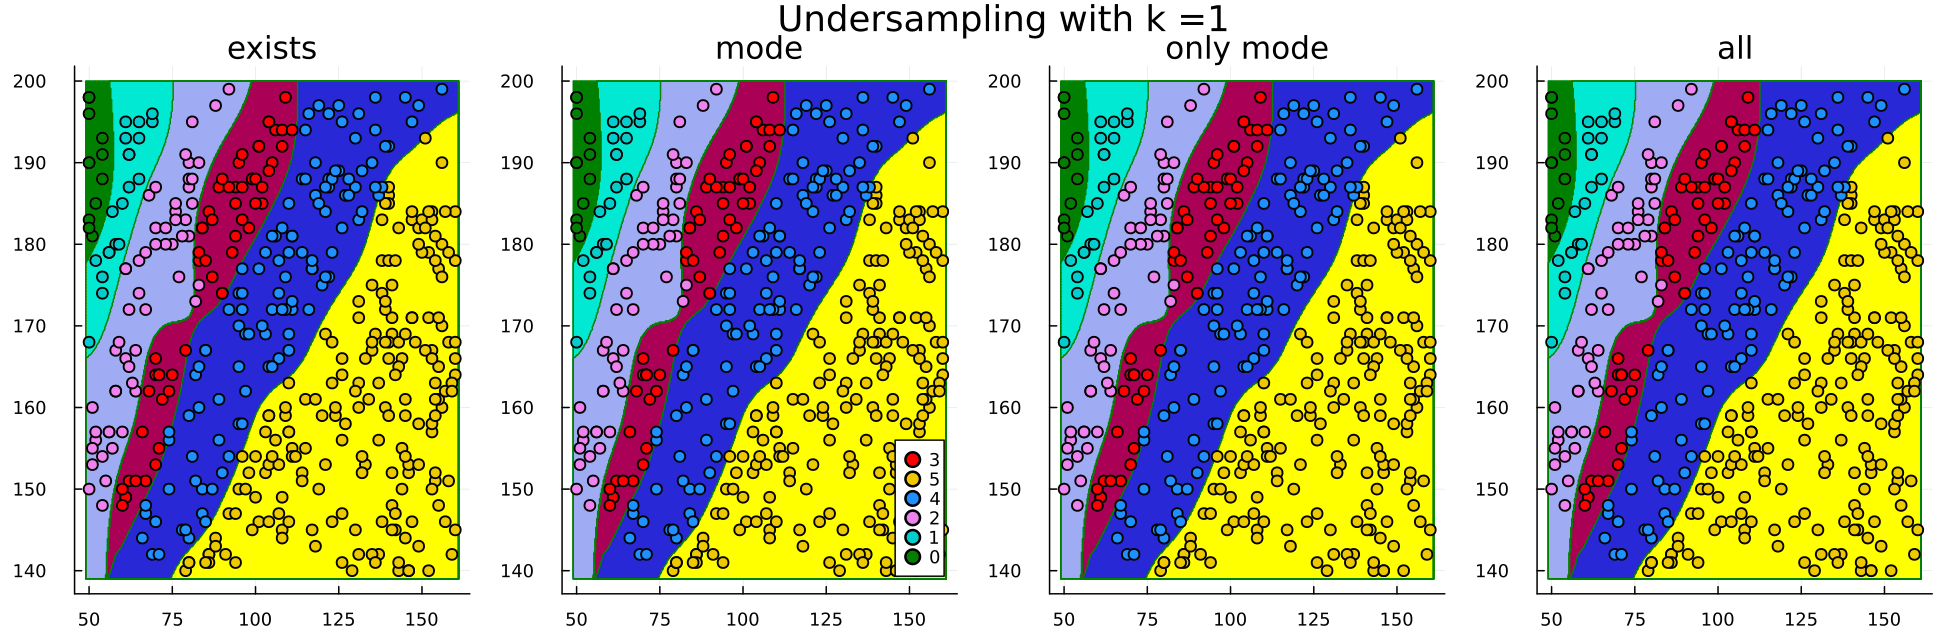

In [28]:
gif(anim, "./assets/enn-k-animation.gif", fps=1)

![enn-gif-hyperparameter](./assets/enn-k-animation.gif)

As we can see, the most constraining condition is `all`. It deletes any point where the label is different than any of the nearest `k` neighbors which also explains why it's the most sensitive to 
the hyperparameter `k`.

In [ ]:
import sys; sys.path.append("..")
from convert import convert_to_md; convert_to_md('effect_of_k_enn')